# 04 — Image Preprocessing & Augmentation

> **Goal:** Preprocess every image to YOLOv8-ready format, then apply lightweight, realistic augmentations — primarily to under-represented classes (Shopping-Cart, Customer-Bagpack, Product-Picked).

**Preprocessing steps (all images):**
1. EXIF auto-orient (fix rotation)
2. Letterbox resize to 640×640 (preserve aspect ratio, pad with grey)
3. Save as high-quality JPEG

**Augmentation (minority classes only — configurable):**
- Horizontal flip  
- Brightness / contrast jitter  
- Gaussian noise  
- Mild blur  
- Slight scale jitter  

**Input:**  `dataset_cleaned/` (NB02 output)  
**Output:** `dataset_preprocessed/` — preprocessed + augmented dataset  
**Logs:**   `logs/04_preprocessing_report_<timestamp>.json`

In [1]:
import subprocess, sys
for pkg in [('cv2','opencv-python'),('yaml','pyyaml'),('tqdm','tqdm'),
            ('numpy','numpy'),('PIL','Pillow'),('matplotlib','matplotlib'),
            ('seaborn','seaborn')]:
    try:
        __import__(pkg[0])
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg[1]])
print('Packages OK.')

Packages OK.


In [2]:
import os
import cv2
import json
import yaml
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib   import Path
from datetime  import datetime
from collections import Counter
from PIL       import Image, ExifTags
import warnings

warnings.filterwarnings('ignore')
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

random.seed(42)
np.random.seed(42)
print('Imports complete.')

Imports complete.


## Configuration

In [3]:
# ── Paths ────────────────────────────────────────────────────
SRC_DIR  = Path('dataset_cleaned')      # NB02 output
OUT_DIR  = Path('dataset_preprocessed') # this notebook's output
LOG_DIR  = Path('logs')
LOG_DIR.mkdir(exist_ok=True)
TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
SPLITS    = ['train', 'valid', 'test']

# Fall back to raw if cleaned dataset is missing
if not SRC_DIR.exists():
    SRC_DIR = Path('DATA_AFTER MERGED')
    print(f'WARNING: dataset_cleaned not found — using {SRC_DIR}')

yaml_path = SRC_DIR / 'data.yaml'
if not yaml_path.exists():
    yaml_path = Path('DATA_AFTER MERGED') / 'data.yaml'
with open(yaml_path) as f:
    data_yaml = yaml.safe_load(f)
CLASS_NAMES = data_yaml['names']
NUM_CLASSES = len(CLASS_NAMES)

# ── Preprocessing settings ───────────────────────────────────
TARGET_SIZE   = 640          # YOLOv8 standard
PAD_COLOR     = (114, 114, 114)  # grey letterbox pad (YOLO convention)
JPEG_QUALITY  = 95

# ── Augmentation settings ────────────────────────────────────
# Classes that need extra samples (by index)
# Shopping-Cart=4 (212), Customer-Bagpack=0 (780), Product-Picked=2 (1051)
MINORITY_CLASSES  = {0, 2, 4}    # augment images containing these classes
AUG_COPIES        = 3            # extra copies per minority image
APPLY_AUG_TO_VAL  = False        # never augment val / test

# Augmentation probabilities
AUG_PARAMS = {
    'hflip_prob':       0.5,
    'brightness_range': (-0.2, 0.2),   # additive factor on [0,1] image
    'contrast_range':   (0.8, 1.2),    # multiplicative factor
    'noise_std':        0.015,         # Gaussian noise std (normalised)
    'blur_prob':        0.3,           # probability of mild blur
    'blur_ksize':       3,             # blur kernel (must be odd)
    'scale_range':      (0.90, 1.10),  # mild scale jitter
}

print(f'Source        : {SRC_DIR.resolve()}')
print(f'Output        : {OUT_DIR.resolve()}')
print(f'Target size   : {TARGET_SIZE}×{TARGET_SIZE}')
print(f'Classes ({NUM_CLASSES})   : {CLASS_NAMES}')
print(f'Minority cls  : {[CLASS_NAMES[i] for i in MINORITY_CLASSES]}')
print(f'Aug copies    : {AUG_COPIES} per minority image (train only)')

Source        : C:\Users\shaho\OneDrive\Desktop\grad\dataset_cleaned
Output        : C:\Users\shaho\OneDrive\Desktop\grad\dataset_preprocessed
Target size   : 640×640
Classes (6)   : ['Customer-Bagpack', 'Product', 'Product-Picked', 'Shopping-Cart', 'normal', 'theft']
Minority cls  : ['Customer-Bagpack', 'Product-Picked', 'normal']
Aug copies    : 3 per minority image (train only)


## Core Functions

In [4]:
IMG_EXTS = ('*.jpg','*.jpeg','*.png','*.JPG','*.JPEG','*.PNG','*.bmp','*.BMP')


def exif_orient(img_bgr: np.ndarray, img_path: Path) -> np.ndarray:
    """
    Rotate image according to EXIF orientation tag using Pillow.
    If no EXIF or non-JPEG, returns the image unchanged.
    """
    try:
        pil_img = Image.open(img_path)
        exif    = pil_img._getexif()
        if exif is None:
            return img_bgr
        orient_tag = next(
            (tag for tag, name in ExifTags.TAGS.items() if name == 'Orientation'), None
        )
        if orient_tag is None or orient_tag not in exif:
            return img_bgr
        orientation = exif[orient_tag]
        rotations = {
            3: cv2.ROTATE_180,
            6: cv2.ROTATE_90_CLOCKWISE,
            8: cv2.ROTATE_90_COUNTERCLOCKWISE,
        }
        if orientation in rotations:
            img_bgr = cv2.rotate(img_bgr, rotations[orientation])
    except Exception:
        pass
    return img_bgr


def letterbox(img: np.ndarray, target: int = 640,
              pad_color: tuple = (114, 114, 114)) -> tuple:
    """
    Resize image to target×target with letterbox padding.
    Returns: (padded_image, scale, (pad_w, pad_h))
    scale and pads are needed to transform YOLO coords.
    """
    h, w = img.shape[:2]
    scale = min(target / w, target / h)
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    pad_w = (target - new_w) / 2.0
    pad_h = (target - new_h) / 2.0
    top    = int(round(pad_h - 0.1))
    bottom = int(round(pad_h + 0.1))
    left   = int(round(pad_w - 0.1))
    right  = int(round(pad_w + 0.1))

    padded = cv2.copyMakeBorder(
        resized, top, bottom, left, right,
        cv2.BORDER_CONSTANT, value=pad_color
    )
    # Ensure exact target size
    padded = cv2.resize(padded, (target, target), interpolation=cv2.INTER_NEAREST)
    return padded, scale, (pad_w, pad_h)


def transform_boxes_letterbox(labels: list, scale: float,
                               pad_w: float, pad_h: float,
                               src_w: int, src_h: int,
                               target: int = 640) -> list:
    """
    Recompute YOLO box coordinates after letterbox resizing.
    Input / output format: 'cls xc yc bw bh' (normalised strings)
    """
    new_labels = []
    for line in labels:
        parts = line.split()
        if len(parts) != 5:
            continue
        cls_id    = parts[0]
        xc, yc, bw, bh = (float(p) for p in parts[1:])

        # Pixel coords in original image
        x_px  = xc * src_w
        y_px  = yc * src_h
        bw_px = bw * src_w
        bh_px = bh * src_h

        # Scale + shift to letterboxed image
        x_lb  = x_px  * scale + pad_w
        y_lb  = y_px  * scale + pad_h
        bw_lb = bw_px * scale
        bh_lb = bh_px * scale

        # Normalise to [0, 1] in target image
        xc_n  = np.clip(x_lb  / target, 0.0, 1.0)
        yc_n  = np.clip(y_lb  / target, 0.0, 1.0)
        bw_n  = np.clip(bw_lb / target, 0.0, 1.0)
        bh_n  = np.clip(bh_lb / target, 0.0, 1.0)

        if bw_n > 1e-4 and bh_n > 1e-4:
            new_labels.append(f'{cls_id} {xc_n:.6f} {yc_n:.6f} {bw_n:.6f} {bh_n:.6f}')
    return new_labels


# ── Augmentation helpers ─────────────────────────────────────

def aug_hflip(img: np.ndarray, labels: list) -> tuple:
    """Horizontal flip image and mirror all bounding boxes."""
    img = cv2.flip(img, 1)
    new_labels = []
    for line in labels:
        parts = line.split()
        cls_id = parts[0]
        xc, yc, bw, bh = (float(p) for p in parts[1:])
        xc = 1.0 - xc   # mirror x-center
        new_labels.append(f'{cls_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}')
    return img, new_labels


def aug_brightness_contrast(img: np.ndarray, params: dict) -> np.ndarray:
    """Adjust brightness and contrast on float32 [0,1] image."""
    img_f  = img.astype(np.float32) / 255.0
    beta   = random.uniform(*params['brightness_range'])
    alpha  = random.uniform(*params['contrast_range'])
    img_f  = np.clip(alpha * img_f + beta, 0.0, 1.0)
    return (img_f * 255).astype(np.uint8)


def aug_gaussian_noise(img: np.ndarray, std: float) -> np.ndarray:
    """Add Gaussian noise."""
    noise = np.random.normal(0, std * 255, img.shape).astype(np.float32)
    noisy = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return noisy


def aug_blur(img: np.ndarray, ksize: int) -> np.ndarray:
    """Apply mild Gaussian blur."""
    ksize = ksize if ksize % 2 == 1 else ksize + 1
    return cv2.GaussianBlur(img, (ksize, ksize), 0)


def aug_scale(img: np.ndarray, labels: list,
              scale_range: tuple, target: int) -> tuple:
    """
    Randomly zoom in/out and re-letterbox to target size.
    Boxes are adjusted accordingly.
    """
    h, w = img.shape[:2]
    scale_factor = random.uniform(*scale_range)
    new_w = max(1, int(w * scale_factor))
    new_h = max(1, int(h * scale_factor))
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    # Re-letterbox to target
    padded, scale, (pad_w, pad_h) = letterbox(resized, target, PAD_COLOR)
    new_labels = transform_boxes_letterbox(
        labels, scale, pad_w, pad_h, new_w, new_h, target
    )
    return padded, new_labels


def apply_augmentation(img: np.ndarray, labels: list,
                        params: dict, target: int) -> tuple:
    """Apply a random combination of augmentations to one image."""
    if random.random() < params['hflip_prob']:
        img, labels = aug_hflip(img, labels)

    img = aug_brightness_contrast(img, params)
    img = aug_gaussian_noise(img, params['noise_std'])

    if random.random() < params['blur_prob']:
        img = aug_blur(img, params['blur_ksize'])

    img, labels = aug_scale(img, labels, params['scale_range'], target)

    return img, labels


print('Functions defined.')

Functions defined.


## Create Output Directories

In [5]:
for split in SPLITS:
    for sub in ('images', 'labels'):
        (OUT_DIR / split / sub).mkdir(parents=True, exist_ok=True)

print(f'Output directories created under {OUT_DIR}/')

Output directories created under dataset_preprocessed/


## Process All Splits

In [7]:
from tqdm import tqdm
proc_stats = {sp: {'processed': 0, 'augmented': 0, 'aug_copies': 0,
                    'failed': 0} for sp in SPLITS}

for split in SPLITS:
    img_src_dir = SRC_DIR / split / 'images'
    lbl_src_dir = SRC_DIR / split / 'labels'
    img_out_dir = OUT_DIR / split / 'images'
    lbl_out_dir = OUT_DIR / split / 'labels'

    if not img_src_dir.exists():
        print(f'WARNING: {img_src_dir} not found — skipping.')
        continue

    images = []
    for ext in IMG_EXTS:
        images.extend(img_src_dir.glob(ext))
    images = sorted(set(images))

    print(f'\n[{split.upper()}] {len(images)} images')
    do_augment = (split == 'train')   # only augment training set

    for img_path in tqdm(images, desc=f'  {split}', unit='img'):
        lbl_path = lbl_src_dir / f'{img_path.stem}.txt'

        # ── Load image ───────────────────────────────────────
        img = cv2.imread(str(img_path))
        if img is None:
            proc_stats[split]['failed'] += 1
            continue

        src_h, src_w = img.shape[:2]

        # ── EXIF orientation ─────────────────────────────────
        img = exif_orient(img, img_path)

        # ── Read label ───────────────────────────────────────
        labels = []
        if lbl_path.exists() and lbl_path.stat().st_size > 0:
            labels = [
                l.strip() for l in
                lbl_path.read_text(encoding='utf-8', errors='replace').splitlines()
                if l.strip()
            ]

        # ── Letterbox to 640×640 ─────────────────────────────
        lb_img, scale, (pad_w, pad_h) = letterbox(img, TARGET_SIZE, PAD_COLOR)
        lb_labels = transform_boxes_letterbox(
            labels, scale, pad_w, pad_h, src_w, src_h, TARGET_SIZE
        )

        # ── Save preprocessed image ──────────────────────────
        out_img_path = img_out_dir / f'{img_path.stem}.jpg'
        cv2.imwrite(str(out_img_path),
                    lb_img,
                    [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])

        out_lbl_path = lbl_out_dir / f'{img_path.stem}.txt'
        out_lbl_path.write_text('\n'.join(lb_labels) + ('\n' if lb_labels else ''),
                                 encoding='utf-8')
        proc_stats[split]['processed'] += 1

        # ── Augmentation (train only, minority classes) ──────
        if do_augment and lb_labels:
            label_classes = {int(l.split()[0]) for l in lb_labels}
            if label_classes & MINORITY_CLASSES:
                proc_stats[split]['augmented'] += 1
                for aug_i in range(AUG_COPIES):
                    aug_img, aug_lbl = apply_augmentation(
                        lb_img.copy(), lb_labels.copy(),
                        AUG_PARAMS, TARGET_SIZE
                    )
                    aug_stem = f'{img_path.stem}_aug{aug_i:02d}'
                    cv2.imwrite(
                        str(img_out_dir / f'{aug_stem}.jpg'),
                        aug_img,
                        [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY]
                    )
                    (lbl_out_dir / f'{aug_stem}.txt').write_text(
                        '\n'.join(aug_lbl) + ('\n' if aug_lbl else ''),
                        encoding='utf-8'
                    )
                    proc_stats[split]['aug_copies'] += 1

print('\nProcessing complete.')

for split, st in proc_stats.items():
    total = st['processed'] + st['aug_copies']
    print(f'  [{split}] original={st["processed"]:,}  '
          f'augmented_src={st["augmented"]:,}  '
          f'aug_copies={st["aug_copies"]:,}  '
          f'total={total:,}')


[TRAIN] 8569 images


  train: 100%|██████████| 8569/8569 [20:10<00:00,  7.08img/s]



[VALID] 1526 images


  valid: 100%|██████████| 1526/1526 [00:16<00:00, 91.03img/s]



[TEST] 740 images


  test: 100%|██████████| 740/740 [00:07<00:00, 97.44img/s]


Processing complete.
  [train] original=8,569  augmented_src=5,338  aug_copies=16,014  total=24,583
  [valid] original=1,526  augmented_src=0  aug_copies=0  total=1,526
  [test] original=740  augmented_src=0  aug_copies=0  total=740


## Write data.yaml

In [8]:
clean_yaml = {
    'path':  str(OUT_DIR.resolve()),
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc':    NUM_CLASSES,
    'names': CLASS_NAMES,
}
with open(OUT_DIR / 'data.yaml', 'w') as f:
    yaml.dump(clean_yaml, f, default_flow_style=False, allow_unicode=True)

print(f'data.yaml → {OUT_DIR / "data.yaml"}')
print()
print('Contents:')
print(open(OUT_DIR / 'data.yaml').read())

data.yaml → dataset_preprocessed\data.yaml

Contents:
names:
- Customer-Bagpack
- Product
- Product-Picked
- Shopping-Cart
- normal
- theft
nc: 6
path: C:\Users\shaho\OneDrive\Desktop\grad\dataset_preprocessed
test: test/images
train: train/images
val: valid/images



## Augmentation Preview

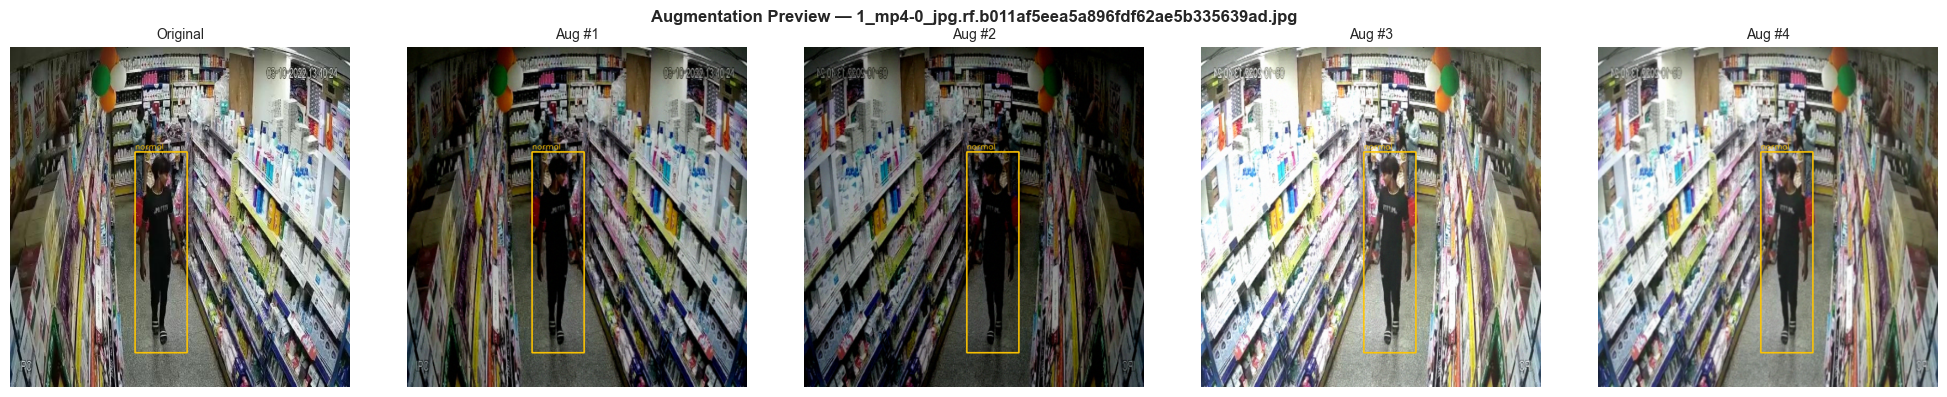

Preview saved → logs\04_augmentation_preview.png


In [9]:
def draw_boxes(img_bgr, labels, class_names, thickness=2):
    """Draw YOLO bounding boxes on an image (BGR)."""
    h, w = img_bgr.shape[:2]
    COLORS = [
        (255, 56,  56),   # 0
        (255, 157,  151), # 1
        (255, 212,  131), # 2
        (0,   255, 112),  # 3
        (0,   197, 255),  # 4
        (142,  28, 255),  # 5
    ]
    out = img_bgr.copy()
    for line in labels:
        parts = line.split()
        if len(parts) != 5:
            continue
        cls_id        = int(parts[0])
        xc, yc, bw, bh = (float(p) for p in parts[1:])
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)
        color = COLORS[cls_id % len(COLORS)]
        cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
        label_txt = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
        cv2.putText(out, label_txt, (x1, max(y1 - 5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
    return out


# Find a minority-class training image to show
preview_img_path = None
preview_lbl_path = None

train_img_dir = OUT_DIR / 'train' / 'images'
train_lbl_dir = OUT_DIR / 'train' / 'labels'

for img_path in sorted(train_img_dir.glob('*.jpg'))[:500]:
    lbl_path = train_lbl_dir / f'{img_path.stem}.txt'
    if not lbl_path.exists() or lbl_path.stat().st_size == 0:
        continue
    lines = lbl_path.read_text().strip().splitlines()
    cls_ids = {int(l.split()[0]) for l in lines if len(l.split()) == 5}
    if cls_ids & MINORITY_CLASSES:
        preview_img_path = img_path
        preview_lbl_path = lbl_path
        break

if preview_img_path:
    orig_img = cv2.imread(str(preview_img_path))
    orig_labels = preview_lbl_path.read_text().strip().splitlines()

    # Generate 4 augmented versions
    aug_images = [orig_img]
    aug_labels_list = [orig_labels]
    for _ in range(4):
        a_img, a_lbl = apply_augmentation(
            orig_img.copy(), orig_labels.copy(), AUG_PARAMS, TARGET_SIZE
        )
        aug_images.append(a_img)
        aug_labels_list.append(a_lbl)

    titles = ['Original'] + [f'Aug #{i}' for i in range(1, 5)]

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(
        f'Augmentation Preview — {preview_img_path.name}',
        fontsize=12, fontweight='bold'
    )
    for ax, img, lbls, title in zip(axes, aug_images, aug_labels_list, titles):
        annotated = draw_boxes(img, lbls, CLASS_NAMES)
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    out_path = LOG_DIR / '04_augmentation_preview.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Preview saved → {out_path}')
else:
    print('No minority-class image found for preview — skipping.')

## Save Processing Report

In [10]:
log_data = {
    'timestamp':    TIMESTAMP,
    'source':       str(SRC_DIR.resolve()),
    'output':       str(OUT_DIR.resolve()),
    'target_size':  TARGET_SIZE,
    'aug_params':   AUG_PARAMS,
    'minority_classes': list(MINORITY_CLASSES),
    'aug_copies':   AUG_COPIES,
    'split_stats':  proc_stats,
    'totals': {
        split: {
            'original':   proc_stats[split]['processed'],
            'aug_copies': proc_stats[split]['aug_copies'],
            'total':      proc_stats[split]['processed'] + proc_stats[split]['aug_copies'],
        }
        for split in SPLITS
    }
}

log_path = LOG_DIR / f'04_preprocessing_report_{TIMESTAMP}.json'
with open(log_path, 'w', encoding='utf-8') as f:
    json.dump(log_data, f, indent=2, default=str)

print(f'Report saved → {log_path}')
print()
print('=' * 52)
print('NOTEBOOK 04 COMPLETE')
print(f'Preprocessed dataset → {OUT_DIR}')
print('Next: run  05_splitting_visualization.ipynb')
print('=' * 52)

Report saved → logs\04_preprocessing_report_20260408_215532.json

NOTEBOOK 04 COMPLETE
Preprocessed dataset → dataset_preprocessed
Next: run  05_splitting_visualization.ipynb
